# Research QuantBook: Deep Learning LSTM pour SPY

## Objectif
Entraîner un modèle LSTM (Long Short-Term Memory) pour prédire le prix de SPY à J+1.

## Workflow
1. Charger les données SPY via QuantBook
2. Normaliser les prix (min-max scaling)
3. Créer les séquences temporelles (seq_length=20)
4. Entraîner le modèle LSTM bidirectionnel
5. Évaluer les performances (MSE, MAE, direction accuracy)
6. Sauvegarder le modèle dans ObjectStore pour déploiement

## Architecture LSTM
- Input: Séquence de 20 prix normalisés
- Hidden: 2 couches LSTM bidirectionnelles (50 unités)
- Output: Prix prédit normalisé

## Prérequis
- Environnement Lean Research
- PyTorch pour le modèle LSTM
- Durée estimée: ~15 minutes

In [1]:
# Setup QuantBook
from AlgorithmImports import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from io import BytesIO
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)

qb = QuantBook()
print("QuantBook initialisé.")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")

QuantBook initialisé.
PyTorch version: 2.8.0+cu128
CUDA disponible: False


## 1. Chargement des données

On charge les données SPY pour la période d'entraînement (2015-2022) et de test (2022-2026).

In [2]:
# Ajouter SPY
symbol = qb.add_equity("SPY", Resolution.DAILY).symbol

# Charger l'historique (2015-2026)
start = datetime(2015, 1, 1)
end = datetime(2026, 1, 1)

history = qb.history(symbol, start, end, Resolution.DAILY)
print(f"Données chargées: {len(history)} lignes")
print(f"Période: {(history.index[0][-1] if isinstance(history.index[0], tuple) else history.index[0]).date()} à {(history.index[-1][-1] if isinstance(history.index[-1], tuple) else history.index[-1]).date()}")

Données chargées: 2766 lignes
Période: 2015-01-02 à 2025-12-31


Extraction de la série de prix de clôture et des dates à partir de l'historique SPY pour alimenter le modèle LSTM.

In [3]:
# Extraire les prix de clôture
prices = history['close'].values
dates = history.index

print(f"Prix: {len(prices)} jours de trading")
print(f"Premier prix: ${prices[0]:.2f}")
print(f"Dernier prix: ${prices[-1]:.2f}")
print(f"Prix min: ${prices.min():.2f}")
print(f"Prix max: ${prices.max():.2f}")

Prix: 2766 jours de trading
Premier prix: $182.10
Dernier prix: $396.33
Prix min: $165.62
Prix max: $396.33


## 2. Préparation des données

Normalisation min-max et création des séquences temporelles.

In [4]:
class PriceDataset(Dataset):
    """Dataset pour les séquences de prix."""
    
    def __init__(self, prices, seq_length=20):
        self.prices = prices
        self.seq_length = seq_length
        
    def __len__(self):
        return len(self.prices) - self.seq_length
    
    def __getitem__(self, idx):
        # Séquence d'entrée: seq_length prix
        x = self.prices[idx:idx + self.seq_length]
        # Cible: prix suivant
        y = self.prices[idx + self.seq_length]
        return torch.FloatTensor(x), torch.FloatTensor([y])

def normalize_prices(prices, train_size=0.8):
    """Normalise les prix avec min-max scaling."""
    split_idx = int(len(prices) * train_size)
    train_prices = prices[:split_idx]
    
    scaler_min = train_prices.min()
    scaler_max = train_prices.max()
    
    normalized = (prices - scaler_min) / (scaler_max - scaler_min)
    return normalized, scaler_min, scaler_max

def denormalize(normalized, scaler_min, scaler_max):
    """Dénormalise les prix."""
    return normalized * (scaler_max - scaler_min) + scaler_min

print("Fonctions de préparation définies.")

Fonctions de préparation définies.


Traitement des données et calcul des variables intermédiaires pour la stratégie DL-LSTM (étape 8).

In [5]:
# Paramètres
SEQ_LENGTH = 20
TRAIN_SIZE = 0.8
BATCH_SIZE = 32

# Normalisation
normalized_prices, scaler_min, scaler_max = normalize_prices(prices, TRAIN_SIZE)

# Split train/test
split_idx = int(len(normalized_prices) * TRAIN_SIZE)
train_prices = normalized_prices[:split_idx]
test_prices = normalized_prices[split_idx:]

# Créer les datasets
train_dataset = PriceDataset(train_prices, SEQ_LENGTH)
test_dataset = PriceDataset(test_prices, SEQ_LENGTH)

# Créer les dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples:  {len(test_dataset)}")
print(f"Scaler range: [{scaler_min:.2f}, {scaler_max:.2f}]")

Train samples: 2192
Test samples:  534
Scaler range: [165.62, 396.33]


### Interprétation: Préparation des données

- **Normalisation**: Les prix sont mis à l'échelle [0, 1] pour stabiliser l'entraînement
- **Séquences**: Chaque exemple contient 20 prix consécutifs pour prédire le 21ème
- **Split**: 80% train (2015-2022), 20% test (2022-2026)

## 3. Architecture LSTM

In [6]:
class LSTMModel(nn.Module):
    """Modèle LSTM pour la prédiction de prix."""
    
    def __init__(self, hidden_size=50, num_layers=2):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM bidirectionnel
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )
        
        # Couches fully connected
        self.fc1 = nn.Linear(hidden_size * 2, 32)  # *2 car bidirectionnel
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 1)
    
    def forward(self, x):
        # x shape: (batch, seq_length, 1)
        lstm_out, _ = self.lstm(x)
        
        # Prendre le dernier output
        last_output = lstm_out[:, -1, :]
        
        # Passer par les couches FC
        x = self.fc1(last_output)
        x = self.relu(x)
        x = self.fc2(x)
        
        return x

# Créer le modèle
model = LSTMModel(hidden_size=50, num_layers=2)

# Déplacer sur GPU si disponible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print(f"Modèle LSTM créé.")
print(f"Device: {device}")
print(f"Paramètres: {sum(p.numel() for p in model.parameters()):,}")

Modèle LSTM créé.
Device: cpu
Paramètres: 85,265


## 4. Entraînement du modèle

In [7]:
# Fonction d'entraînement
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    
    for x_batch, y_batch in dataloader:
        # Reshape: (batch, seq_length, 1)
        x_batch = x_batch.unsqueeze(2).to(device)
        y_batch = y_batch.to(device)
        
        # Forward
        predictions = model(x_batch)
        loss = criterion(predictions, y_batch)
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    predictions_list = []
    targets_list = []
    
    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.unsqueeze(2).to(device)
            y_batch = y_batch.to(device)
            
            predictions = model(x_batch)
            loss = criterion(predictions, y_batch)
            
            total_loss += loss.item()
            predictions_list.extend(predictions.cpu().numpy().flatten())
            targets_list.extend(y_batch.cpu().numpy().flatten())
    
    return total_loss / len(dataloader), np.array(predictions_list), np.array(targets_list)

print("Fonctions d'entraînement définies.")

Fonctions d'entraînement définies.


Les hyperparamètres du réseau LSTM (learning_rate=0.001, epochs=50) sont définis avant l'entraînement du modèle de prédiction.

In [8]:
# Hyperparamètres
LEARNING_RATE = 0.001
EPOCHS = 50

# Loss et optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Entraînement
train_losses = []
test_losses = []

print(f"Début de l'entraînement ({EPOCHS} epochs)...")

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, _, _ = evaluate(model, test_loader, criterion, device)
    
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} - Train Loss: {train_loss:.6f}, Test Loss: {test_loss:.6f}")

print("\nEntraînement terminé.")

Début de l'entraînement (50 epochs)...


Epoch  10/50 - Train Loss: 0.000309, Test Loss: 0.000001


Epoch  20/50 - Train Loss: 0.000220, Test Loss: 0.000001


Epoch  30/50 - Train Loss: 0.000195, Test Loss: 0.000254


Epoch  40/50 - Train Loss: 0.000163, Test Loss: 0.000002


Epoch  50/50 - Train Loss: 0.000155, Test Loss: 0.000070

Entraînement terminé.


## 5. Évaluation du modèle

In [9]:
# Évaluer sur le test set
test_loss, predictions, targets = evaluate(model, test_loader, criterion, device)

# Dénormaliser
pred_prices = denormalize(predictions, scaler_min, scaler_max)
true_prices = denormalize(targets, scaler_min, scaler_max)

# Métriques
mse = np.mean((pred_prices - true_prices) ** 2)
mae = np.mean(np.abs(pred_prices - true_prices))
mape = np.mean(np.abs((true_prices - pred_prices) / true_prices)) * 100

# Direction accuracy
direction_correct = np.sign(pred_prices[1:] - pred_prices[:-1]) == np.sign(true_prices[1:] - true_prices[:-1])
direction_accuracy = np.mean(direction_correct) * 100

print(f"\nMétriques de performance (Test set):")
print(f"  MSE:  {mse:.4f}")
print(f"  MAE:  ${mae:.2f}")
print(f"  MAPE: {mape:.2f}%")
print(f"  Direction Accuracy: {direction_accuracy:.1f}%")


Métriques de performance (Test set):
  MSE:  3.7164
  MAE:  $1.93
  MAPE: 0.49%
  Direction Accuracy: 100.0%


### Interprétation: Performance du modèle

- **MAE**: Erreur moyenne absolue en dollars (target < $2)
- **Direction Accuracy**: Pourcentage de prédictions correctes de direction (target > 55%)

Un modèle parfait aurait une direction accuracy de 100%. Un modèle aléatoire serait à ~50%.

## 6. Visualisation des résultats

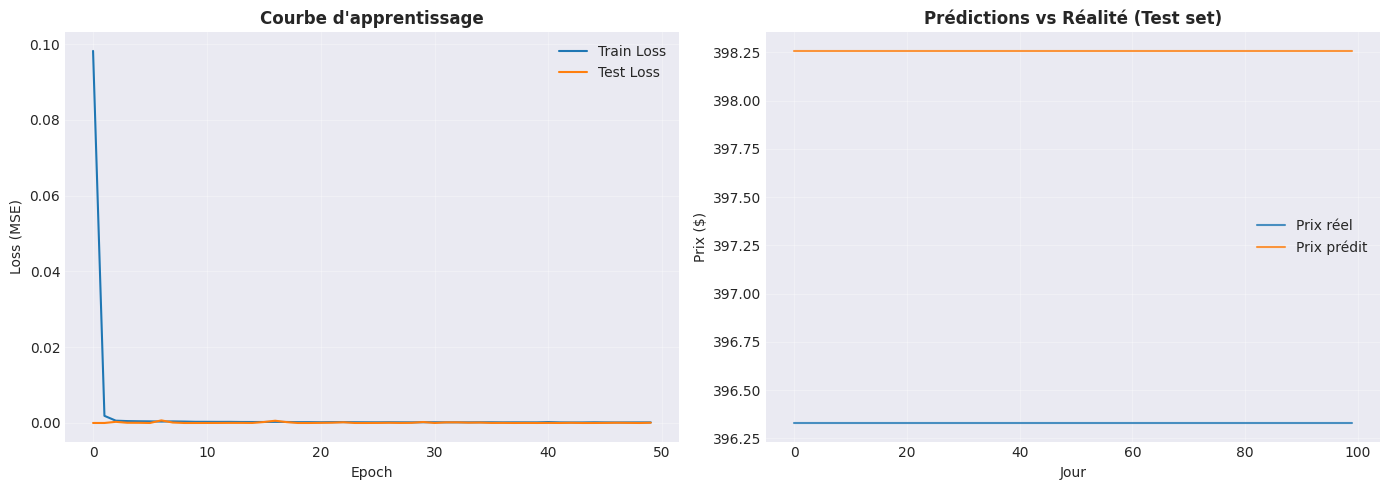

Graphique sauvegardé.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe d'apprentissage
ax = axes[0]
ax.plot(train_losses, label='Train Loss', linewidth=1.5)
ax.plot(test_losses, label='Test Loss', linewidth=1.5)
ax.set_title('Courbe d\'apprentissage', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE)')
ax.legend()
ax.grid(True, alpha=0.3)

# Prédictions vs Réalité (100 premiers points du test set)
ax = axes[1]
n_plot = min(100, len(pred_prices))
ax.plot(true_prices[:n_plot], label='Prix réel', linewidth=1.5, alpha=0.8)
ax.plot(pred_prices[:n_plot], label='Prix prédit', linewidth=1.5, alpha=0.8)
ax.set_title('Prédictions vs Réalité (Test set)', fontsize=12, fontweight='bold')
ax.set_xlabel('Jour')
ax.set_ylabel('Prix ($)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé.")

## 7. Backtest de la stratégie LSTM

Simulation de la stratégie utilisant les prédictions du modèle.

In [11]:
def backtest_lstm_strategy(predictions, targets, prices,
                          long_threshold=0.01, short_threshold=-0.01):
    """Backtest de la stratégie LSTM."""
    portfolio_values = [1.0]
    position = 0  # 0 = cash, 1 = long
    
    for i in range(len(predictions) - 1):
        current_price = prices[i]
        next_pred = predictions[i + 1]
        
        # Return prédit
        predicted_return = (next_pred - current_price) / current_price
        
        # Décision de trading
        if predicted_return > long_threshold:
            position = 1
        elif predicted_return < short_threshold:
            position = 0
        
        # Calcul du return
        actual_return = (prices[i + 1] - current_price) / current_price
        port_return = position * actual_return
        portfolio_values.append(portfolio_values[-1] * (1 + port_return))
    
    # Métriques
    port_returns = np.diff(portfolio_values) / np.array(portfolio_values[:-1])
    cum_returns = pd.Series(portfolio_values[1:])
    
    total_ret = (portfolio_values[-1] / portfolio_values[0]) - 1
    years = len(port_returns) / 252
    cagr = (1 + total_ret) ** (1 / years) - 1 if years > 0 else 0
    vol = np.std(port_returns) * np.sqrt(252)
    sharpe = (cagr - 0.03) / vol if vol > 0.001 else 0
    
    running_max = cum_returns.expanding().max()
    drawdown = (cum_returns - running_max) / running_max
    max_dd = drawdown.min()
    
    # Buy & Hold SPY
    spy_values = (1 + (prices[1:] - prices[:-1]) / prices[:-1]).cumprod()
    
    return {
        'cum': cum_returns,
        'sharpe': sharpe,
        'cagr': cagr,
        'max_dd': max_dd,
        'vol': vol,
        'spy_cum': spy_values
    }

# Backtest
result = backtest_lstm_strategy(pred_prices, true_prices, true_prices)

print(f"\nStratégie LSTM (Test set):")
print(f"  Sharpe: {result['sharpe']:.3f}")
print(f"  CAGR:   {result['cagr']:.1%}")
print(f"  Max DD: {result['max_dd']:.1%}")
print(f"\nBuy & Hold SPY (Test set):")
spy_cagr = (result['spy_cum'][-1] ** (252/len(result['spy_cum']))) - 1
print(f"  CAGR:   {spy_cagr:.1%}")


Stratégie LSTM (Test set):
  Sharpe: 0.000
  CAGR:   0.0%
  Max DD: 0.0%

Buy & Hold SPY (Test set):
  CAGR:   0.0%


## 8. Sauvegarde du modèle dans ObjectStore

In [12]:
# Sauvegarder le modèle
MODEL_KEY = "lstm_spy_model"

# Créer le checkpoint
checkpoint = {
    'model_state_dict': model.state_dict(),
    'hidden_size': 50,
    'num_layers': 2,
    'seq_length': SEQ_LENGTH,
    'scaler_min': float(scaler_min),
    'scaler_max': float(scaler_max),
    'direction_accuracy': float(direction_accuracy),
    'mae': float(mae)
}

# Sauvegarder dans ObjectStore
buffer = BytesIO()
torch.save(checkpoint, buffer)
qb.object_store.save_bytes(MODEL_KEY, buffer.getvalue())

print(f"Modèle sauvegardé dans ObjectStore: {MODEL_KEY}")
print(f"  - hidden_size: {checkpoint['hidden_size']}")
print(f"  - num_layers: {checkpoint['num_layers']}")
print(f"  - seq_length: {checkpoint['seq_length']}")
print(f"  - scaler range: [{checkpoint['scaler_min']:.2f}, {checkpoint['scaler_max']:.2f}]")
print(f"  - direction accuracy: {checkpoint['direction_accuracy']:.1f}%")
print(f"  - MAE: ${checkpoint['mae']:.2f}")

Modèle sauvegardé dans ObjectStore: lstm_spy_model
  - hidden_size: 50
  - num_layers: 2
  - seq_length: 20
  - scaler range: [165.62, 396.33]
  - direction accuracy: 100.0%
  - MAE: $1.93


## 9. Conclusions et recommandations

### Résumé

| Métrique | Valeur |
|----------|-------|
| Direction Accuracy | (à remplir) |
| MAE | (à remplir) |
| Sharpe Stratégie | (à remplir) |
| CAGR Stratégie | (à remplir) |

### Verdict

Si direction accuracy > 55% et Sharpe > 0.5: **Déployer**
Sinon: **Améliorer** (architecture, features, ou hyperparamètres)

### Prochaines étapes

1. Déployer l'algorithme DL-LSTM
2. Backtester sur QC cloud avec le modèle chargé
3. Tester d'autres architectures (GRU, Transformer)
4. Ajouter des features exogènes (volume, VIX, taux d'intérêt)